In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =  pd.read_csv("weight-height.csv")

In [4]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
df.sample(7)

,Gender,Height,Weight
7538,Female,58.531246,110.589778
6345,Female,64.116023,134.301425
4576,Male,70.830481,204.697662
9360,Female,61.912254,136.494215
1422,Male,72.369934,224.603811
140,Male,68.860090,169.556821
2023,Male,69.435625,178.366555


In [6]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


In [19]:
df.shape

(10000, 3)

In [7]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

C:\Users\swaya\AppData\Local\Temp\ipykernel_13712\953631909.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])
C:\Users\swaya\AppData\Local\Temp\ipykernel_13712\953631909.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


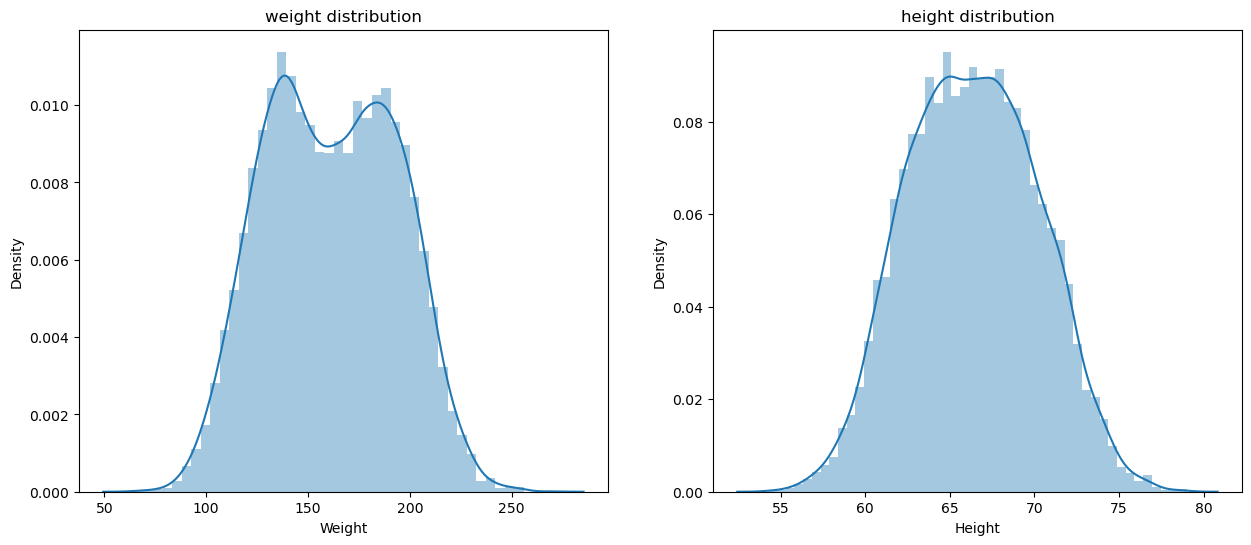

In [8]:
plt.figure(figsize=(15 ,6))
plt.subplot(1 ,2 ,1)
sns.distplot(df['Weight'])
plt.title("weight distribution")

plt.subplot(1,2,2)
sns.distplot(df['Height'])
plt.title("height distribution")
plt.show()

<Axes: ylabel='Height'>

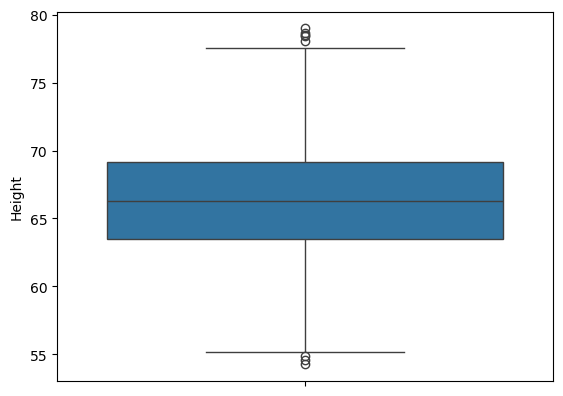

In [9]:
sns.boxplot(df['Height'])

In [10]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

74.7857900583366

In [20]:
df[df['Height'] > upper_limit].value_counts

<bound method DataFrame.value_counts of      Gender     Height      Weight
23     Male  75.205974  228.761781
190    Male  76.709835  235.035419
197    Male  75.944460  231.924749
202    Male  75.140821  224.124271
215    Male  74.795375  232.635403
...     ...        ...         ...
4565   Male  75.690384  223.587548
4569   Male  77.547186  242.041173
4701   Male  76.732446  241.686601
4721   Male  75.330847  240.440816
4825   Male  74.975231  214.495489

[100 rows x 3 columns]>

In [13]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

58.13441158671655

In [21]:
df[df['Height'] < lower_limit].value_counts

<bound method DataFrame.value_counts of       Gender     Height      Weight
5026  Female  56.547975   84.872124
5074  Female  56.159458   90.815256
5122  Female  57.103869   93.506316
5123  Female  56.445685   96.640245
5162  Female  57.961936  112.226984
...      ...        ...         ...
9761  Female  56.975279   90.341784
9825  Female  55.979198   85.417534
9895  Female  57.740192   93.652957
9904  Female  57.028857  101.202551
9978  Female  57.375759  114.192209

[100 rows x 3 columns]>

## trimming

In [17]:
new_df = df[(df['Height'] < upper_limit) & (df['Height'] > lower_limit)]


In [18]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


C:\Users\swaya\AppData\Local\Temp\ipykernel_13712\1788562762.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])
C:\Users\swaya\AppData\Local\Temp\ipykernel_13712\1788562762.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


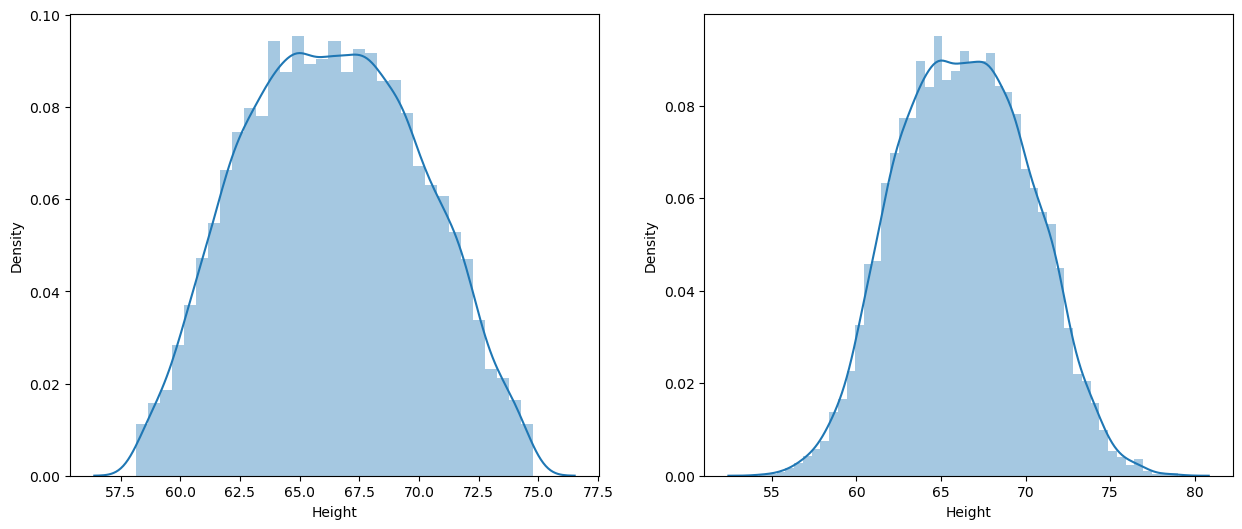

In [26]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.distplot(new_df['Height'])

plt.subplot(1,2,2)
sns.distplot(df['Height'])
plt.show()

<Axes: ylabel='Height'>

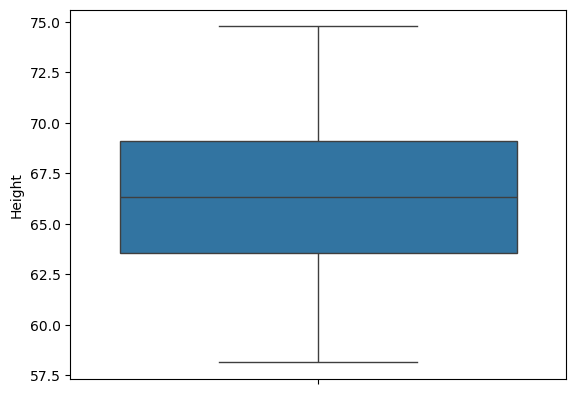

In [28]:
sns.boxplot(new_df['Height'])

### capping

In [29]:
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

In [30]:
df.shape

(10000, 3)

In [31]:
df.describe

<bound method NDFrame.describe of       Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]>

C:\Users\swaya\AppData\Local\Temp\ipykernel_13712\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

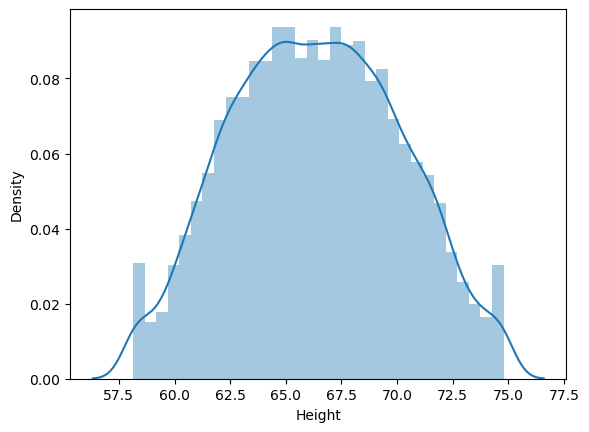

In [32]:
sns.distplot(df['Height'])